# 1. Library

In [1]:
import tensorflow as tf
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 2. Text Corpus and cleaning


In [2]:
corpus = '''
A GPU is a specialized processor designed to accelerate parallel computations, making it highly effective
for deep learning and neural network training. Recurrent Neural Networks (RNNs) are a class of neural networks
that process sequential data by maintaining a hidden state that carries information from previous time steps.
However, traditional RNNs often struggle with long-term dependencies due to the vanishing gradient problem.
Long Short-Term Memory (LSTM) networks address this issue by introducing memory cells and gating mechanisms
that control the flow of information. As a result, LSTM models are widely used for tasks such as language
modeling, text generation, speech recognition, and time-series forecasting. Combining LSTM architectures
with GPU acceleration enables faster training and more efficient processing of large datasets.
'''
corpus = corpus.lower()
corpus = re.sub(r"[^a-z0-9\s]", " ", corpus)
lines = [re.sub(r"\s+", " ", l).strip() for l in corpus.split("\n") if l.strip()]
corpus = "\n".join(lines)
print(corpus)

a gpu is a specialized processor designed to accelerate parallel computations making it highly effective
for deep learning and neural network training recurrent neural networks rnns are a class of neural networks
that process sequential data by maintaining a hidden state that carries information from previous time steps
however traditional rnns often struggle with long term dependencies due to the vanishing gradient problem
long short term memory lstm networks address this issue by introducing memory cells and gating mechanisms
that control the flow of information as a result lstm models are widely used for tasks such as language
modeling text generation speech recognition and time series forecasting combining lstm architectures
with gpu acceleration enables faster training and more efficient processing of large datasets


# 3. Tokenization

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 92
X shape: (115, 18)
y shape: (115,)


# 4. Models

# Model 1: RNN
Epoch: 100, Optimizer: "Adam"



In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


# Model 2: LSTM
Epoch: 100, Optimizer: "Adam"

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)

# Model 3: GRU
Epoch: 100, Optimizer: "Adam"

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)

In [7]:
print(f"Losses\n RNN: {rnn_history.history['loss'][-1]:.2f} "
      f"LSTM: {lstm_history.history['loss'][-1]:.2f} "
      f"GRU: {gru_history.history['loss'][-1]:.2f}")

Losses
 RNN: 0.40 LSTM: 1.73 GRU: 0.58


## 5. Optimization Trajectory

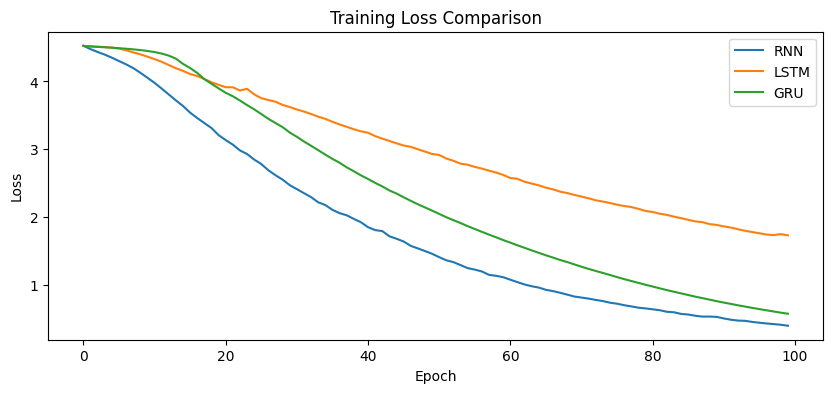

In [8]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

> **Learning**
- On 100 epochs these three models loss were quite far — RNN around 0.40,
GRU around 0.58, and LSTM around 1.73. LSTM is supposed to be then simple RNN but it gave we worst loss comparatively because the corpus here is small. So according to me the simple RNN can just
learned it quickly but the LSTM has many more gates to tune and it works best with large corpus
- GRU is the update form of LSTM so it worked better than LSTM on short corpus too

# 6. Text Generation Function

In [9]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 7. Generate Text Samples

In [10]:
print("Seed: ", "As a result")
print("RNN :", generate_text(rnn_model, "As a result", 5))
print("LSTM:", generate_text(lstm_model, "As a result", 5))
print("GRU :", generate_text(gru_model, "As a result", 5))

Seed:  As a result
RNN : As a result lstm networks a this issue
LSTM: As a result and and and and efficient
GRU : As a result enables faster training and more


- the RNN produced a sensible continuation
- the GRU stayed mostly on-topic
- the LSTM repeated the word processor a few times.

# 8. Model with better parameters

# Model 1: RNN
Epochs: 200, Hidden: 128, Dimension: 64

In [11]:
rnn_model_200 = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model_200.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_model_200.summary()
rnn_history_200 = rnn_model_200.fit(X, y, epochs=200, verbose=0)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Model 2: LSTM
Epochs: 200, Hidden: 128, Dimension: 64

In [12]:
lstm_model_200 = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model_200.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_model_200.summary()
lstm_history_200 = lstm_model_200.fit(X, y, epochs=200, verbose=0)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Model 3: GRU
Epochs: 200, Hidden: 128, Dimension: 64

In [13]:
gru_model_200 = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model_200.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_model_200.summary()
gru_history_200 = gru_model_200.fit(X, y, epochs=200, verbose=0)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
print(f"Losses\n RNN: {rnn_history_200.history['loss'][-1]:.2f} "
      f"LSTM: {lstm_history_200.history['loss'][-1]:.2f} "
      f"GRU: {gru_history_200.history['loss'][-1]:.2f}")

Losses
 RNN: 0.02 LSTM: 0.15 GRU: 0.03


#9. Generate Text Samples
- Generating 10 words

In [15]:
print("RNN :", generate_text(rnn_model_200, "traditional RNNs often", 10))
print("LSTM:", generate_text(lstm_model_200, "traditional RNNs often", 10))
print("GRU :", generate_text(gru_model_200, "traditional RNNs often", 10))

RNN : traditional RNNs often struggle with long term dependencies due to the vanishing gradient
LSTM: traditional RNNs often often struggle with long term dependencies due to the vanishing
GRU : traditional RNNs often struggle with long term dependencies due to the vanishing gradient


- We can clearly see here GRU and RNN worked better than LSTM.
- LSTM didn't worked well as it works better with large corpus.
- RNN worked better than LSTM as it is good for short corpus with simple architecture.

#10. Model Comparision

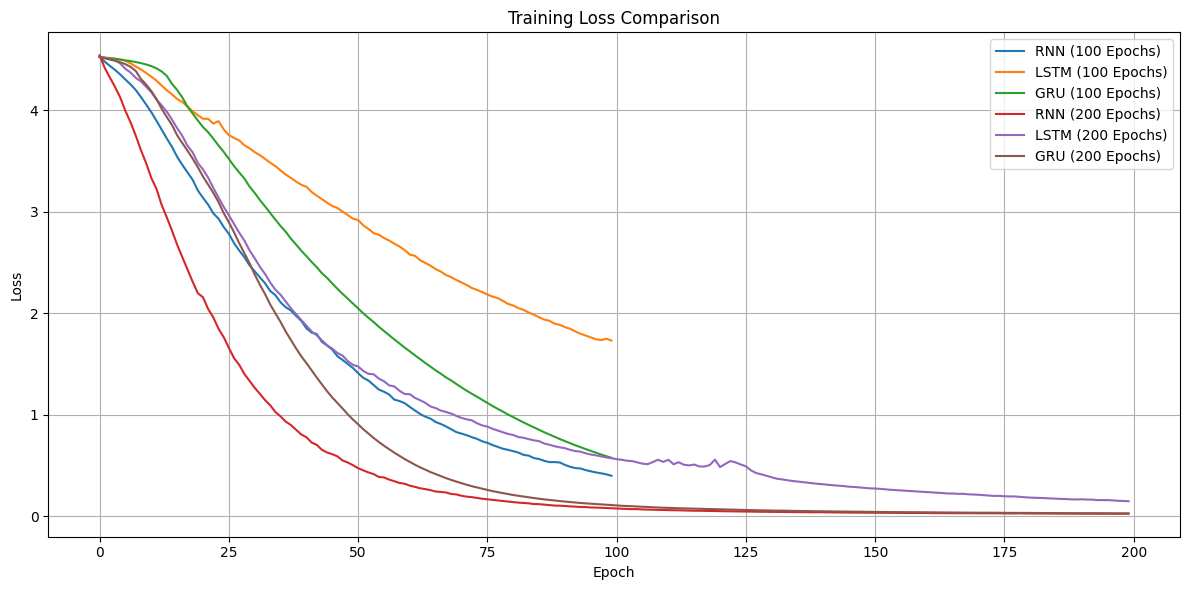

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# 100 Epoch Models
plt.plot(rnn_history.history['loss'], label='RNN (100 Epochs)')
plt.plot(lstm_history.history['loss'], label='LSTM (100 Epochs)')
plt.plot(gru_history.history['loss'], label='GRU (100 Epochs)')

# 200 Epoch Models
plt.plot(rnn_history_200.history['loss'], label='RNN (200 Epochs)')
plt.plot(lstm_history_200.history['loss'], label='LSTM (200 Epochs)')
plt.plot(gru_history_200.history['loss'], label='GRU (200 Epochs)')

plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout();
plt.show()


**Learning**
- With the 100-epoch the SimpleRNN reached the lowest loss and it works better with small corpus compare to LSTM and GRU. Extra gates in LSTM/GRU make these models takes longer time to train.
- After increasing the embedding, hidden and epochs all 3 model retained better score and perform better than the previous models.
- So LSTM works better with large corpus and when we use better Epochs, parameter it gives better results. Simple RNN is works better comparitively on small corpus. GRU is workes well for both small and long corpus